# Lucky-Number-8 — a quantitative teardown 🔬
### A trailing-digit two-proportion contrast (China − control) · a one-sample-*t* event battery on FXI−EEM around 8/8 · a random-window placebo · a leave-one-out jackknife · two seeded positive controls

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![8--clustering%3F: Busted](https://img.shields.io/badge/8--clustering%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim has real academic backing — but almost all of it is measured where **humans set the price** (Brown & Mitchell 2008 on A-share order books; Bhattacharya et al. 2018 on Taiwanese limit orders; Hirshleifer, Jian & Zhang 2018 on IPO digits). The job here is to test whether the fingerprint survives onto the **secondary US tape**, in the trailing digit *and* in the returns around 8/8, with the right inference unit and the round-number confound differenced out.

> ⚠️ **Data note.** yfinance, `auto_adjust=False` → raw Close (digit test) + Adj Close (returns). FXI/EEM panel 2004-10-08→2026-06-30; 15 China ADRs + 15 US controls for the digit test; 21 8/8 events 2005→2025. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `d880312d91f3`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from lucky_number_8 import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=5.0)
    INC = EV[EV["included"]]
    REP = st.digit_report(PRICES)
else:
    PRICES = EV = INC = REP = None
print("real cache present:", HAVE_REAL, "| lucky dates:", len(data.LUCKY_DATES),
      "| resolved:", (0 if INC is None else len(INC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_dates': 21, 'n_included': 21, 'fp': 'd880312d91f3', 'panel_rows': 5465, 'span_lo': '2004-10-08', 'span_hi': '2026-06-30', 'day_mean': 0.387, 'day_t': 2.273, 'day_hit': 13, 'day_n': 21, 'day_wlo': 40.9, 'day_whi': 79.2, 'wk_mean': 0.295, 'wk_t': 0.693, 'wk_hit': 12, 'wk_n': 21, 'wk_wlo': 36.5, 'wk_whi': 75.5, 'pl_day_p': 0.043, 'pl_day_plmean': -0.005, 'pl_day_plsd': 0.224, 'pl_wk_p': 0.242, 'pl_wk_plmean': -0.03, 'pl_wk_plsd': 0.478, 'day_cap_g': 0.387, 'day_cap_n5': 0.287, 'day_cap_t5': 1.69, 'day_cap_n10': 0.187, 'day_cap_t10': 1.1, 'wk_cap_g': 0.295, 'wk_cap_n5': 0.195, 'wk_cap_t5': 0.46, 'wk_cap_n10': 0.095, 'wk_cap_t10': 0.22, 'jk_lo': 1.956, 'jk_hi': 2.806, 'jk_below2': 4, 'jk_n': 21, 'y2008_day': 2.263, 'y2008_wk': -3.688, 'car': {-5: 0.319, -4: 0.294, -3: 0.394, -2: 0.193, -1: 0.0, 0: 0.387, 1: 0.336, 2: 0.352, 3: 0.458, 4: 0.295, 5: 0.476}, 'synA_null_mean': -0.13, 'synA_null_sd': 1.52, 'synA_null_fire': 2, 'synA_seeds': 20, 'synA_p1_t': 2.49, 'synA_p2_t': 6.62, 'china_n': 45997, 'control_n': 82602, 'n_china': 15, 'n_control': 15, 'china_freq': [12.286, 9.655, 9.531, 9.546, 9.703, 10.331, 9.627, 9.64, 9.909, 9.772], 'control_freq': [11.014, 9.948, 9.771, 9.828, 9.669, 10.208, 9.907, 9.921, 9.762, 9.972], 'china_chi2': 289.6, 'control_chi2': 110.6, 'chi_crit': 16.919, 'z8_china': 9.909, 'z8_control': 9.762, 'z8_diff': 0.147, 'z8': 0.85, 'z8_p': 0.396, 'z4_china': 9.703, 'z4_control': 9.669, 'z4_diff': 0.034, 'z4': 0.2, 'z4_p': 0.845, 'z0_china': 12.286, 'z0_control': 11.014, 'z0_diff': 1.271, 'z0': 6.86, 'z0_p': 0.0, 'synB_null_fire': 0, 'synB_null_z8mean': -0.3, 'synB_p2_z8': 14.32, 'synB_p2_chi2': 384.8}


real cache present: True | lucky dates: 21 | resolved: 21


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 8/8 lucky-day AR **+0.387%**, *t* = **2.273**, placebo *p* = **0.043** — but week *t* = 0.69, and 4/21 jackknife drops (incl. 08/08/08) fall below 2 |
| **Tradability** | `MIRAGE` | lucky-day net *t* = 1.69 (5 bps) / 1.10 (10 bps); ~39 bps/yr gross |
| **8-clustering?** | `BUSTED` | digit-8 China−control *z* = +0.85 (*p* = 0.40); digit-0 *z* = +6.86 (round-number, not 8) |

> 💡 In plain words: prices cluster, but on 0 not 8; and the only tape whisper around 8/8 is a fragile one-day tick that costs erase.

## 1 · The claim, steelmanned

**Part A (clustering).** Let $d_p = \lfloor 100p \rceil \bmod 10$ be the trailing cent digit of a raw close $p$. Under a no-superstition null on a $0.01-tick venue, $P(d=k)$ is common to Chinese and non-Chinese names, so the culture-specific test is the **two-proportion z** of $P_{\text{China}}(d{=}8) - P_{\text{control}}(d{=}8)$ (and the same for $d{=}4$). This cancels the universal round-number (0/5) structure. $H_1$: China shows an **8-excess** and a **4-deficit**.

**Part B (the 8/8 premium).** Let $r^{FXI}_t, r^{EEM}_t$ be total-return log-changes. For each year $y$, day(-1) is the last session before Aug 8, day(0) the first on/after. The abnormal return is

$$AR_y(k) = \left(\tfrac{P^{FXI}_{-1+k}}{P^{FXI}_{-1}}-1\right) - \left(\tfrac{P^{EEM}_{-1+k}}{P^{EEM}_{-1}}-1\right),\quad k\in\{1,5\}.$$

Because 8/8 is **calendar-known**, there is no look-ahead: the window is itself an executable trade. Each year is one independent event → the primary statistic is a **one-sample t across years** (n = 21), not a daily panel. $H_2$: $E[AR(k)] > 0$.

We find **Part A not supported** (no 8-excess, no 4-deficit; clustering is on 0); **Part B supported only at k=1, fragile, and gone net of costs**.

## 2 · So what? — inference design

The digit test pools ~46k China + ~83k control closes; the honest hazard is **serial dependence** (consecutive closes are correlated), which inflates a naive χ² p-value. Two guards: (1) read **effect sizes**, not the pooled p; (2) the **China−control contrast** cancels the shared round-number structure, so a non-zero digit-8 z is culture-specific by construction. The event test has n = 21 independent years → one-sample *t*, a Wilson hit-rate, a 20×200 random-window placebo, and a leave-one-out jackknife on any cut that clears the bar. Two synthetic positive controls confirm both detectors fire on a planted effect and stay quiet on the null.

## 3 · How we'd know — the protocol

- **Digit sample.** 15 China ADRs (45,997 raw closes) vs 15 US controls (82,602); trailing cent digit; two-proportion z on 8, 4 (and 0 for context); pooled χ²(9) with caveat.
- **Event calendar.** 21 8/8 dates 2005→2025, all with FXI+EEM coverage; abnormal return vs EEM at k ∈ {1, 5}.
- **Headline.** One-sample *t* + Wilson hit rate.
- **Robustness.** 20×200 random-window placebo; leave-one-out jackknife.
- **Execution.** Calendar-known → zero look-ahead; capture = same window net of 2× one-way cost × NAV.
- **Controls.** (A) synthetic paired world, planted 8/8 bump; (B) synthetic digit stream, planted 8-excess. Neither may fire on its null.

## 4 · The teardown

### 4a · Trailing-digit clustering — the China−control contrast

Both baskets reject Uniform(1/10), but the decisive question is whether China shows an 8-excess *over the control* (which cancels round numbers).

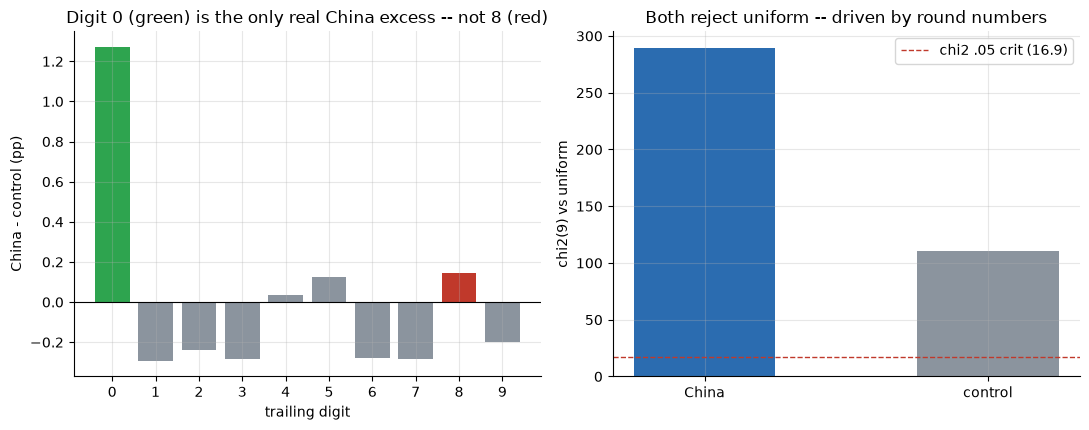

digit 8: China-control z = +0.85  (p=0.396)
digit 4: China-control z = +0.20
digit 0: China-control z = +6.86


In [2]:
if HAVE_REAL:
    cf = [100*c/REP['china_n'] for c in REP['china_counts']]
    uf = [100*c/REP['control_n'] for c in REP['control_counts']]
    z8, z4, z0 = REP['z8'], REP['z4'], st.two_proportion_z(
        REP['china_counts'][0], REP['china_n'], REP['control_counts'][0], REP['control_n'])
    c8, c2 = REP['china_chi2']['chi2'], REP['control_chi2']['chi2']
    z8v, z4v, z0v = z8['z'], z4['z'], z0['z']
else:
    cf, uf = R['china_freq'], R['control_freq']
    z8v, z4v, z0v = R['z8'], R['z4'], R['z0']; c8, c2 = R['china_chi2'], R['control_chi2']
diff = [cf[d]-uf[d] for d in range(10)]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4))
b = a1.bar(range(10), diff, color=[RED if d==8 else (GREEN if d==0 else GREY) for d in range(10)])
a1.axhline(0, c='k', lw=.8); a1.set_xticks(range(10))
a1.set_xlabel('trailing digit'); a1.set_ylabel('China - control (pp)')
a1.set_title('Digit 0 (green) is the only real China excess -- not 8 (red)')
a2.bar(['China', 'control'], [c8, c2], color=['#2b6cb0', GREY], width=.5)
a2.axhline(R['chi_crit'], ls='--', c=RED, lw=1, label='chi2 .05 crit (16.9)')
a2.set_ylabel('chi2(9) vs uniform'); a2.legend()
a2.set_title('Both reject uniform -- driven by round numbers')
plt.tight_layout(); plt.show()
print(f'digit 8: China-control z = {z8v:+.2f}  (p={R["z8_p"]:.3f})')
print(f'digit 4: China-control z = {z4v:+.2f}')
print(f'digit 0: China-control z = {z0v:+.2f}')

> 💡 In plain words: the digit-8 China−control z is **+0.85** (*p* = 0.40) — nothing; the death-digit 4 is **+0.20** — nothing. The one significant China-specific excess is digit **0** (z = **+6.86**): Chinese ADRs cluster harder on round `.x0` prices. That's Harris (1991) round-number preference (arguably amplified by retail flow), **not** the lucky 8. The superstition's price fingerprint does not survive onto the US tape. **Part A / clustering: BUSTED.**

### 4b · The 8/8 premium — one-sample t, two horizons, placebo each

('day (k=1)', 21, 0.3869947557307793, 2.272786462895237, 13, 21, 0.04325)
('week (k=5)', 21, 0.2946257886361846, 0.6932955099713685, 12, 21, 0.2415)


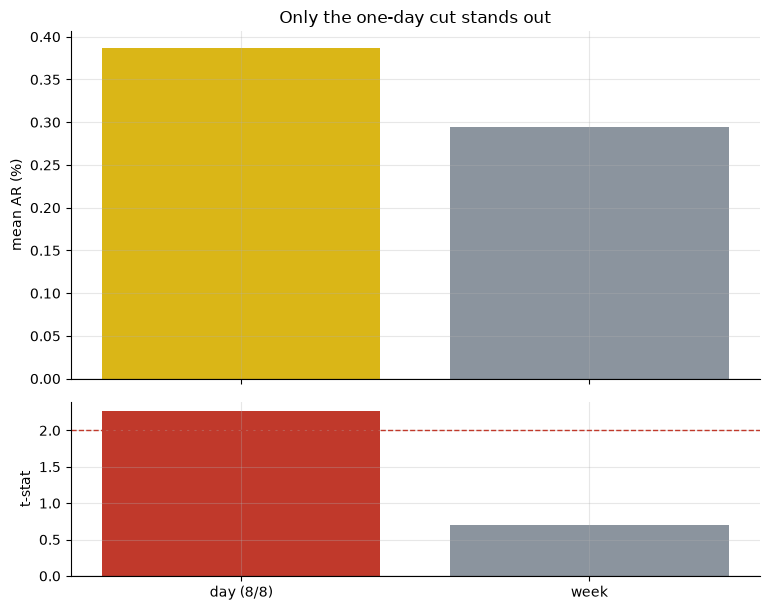

In [3]:
if HAVE_REAL:
    rows = []
    for label, col, k in (('day (k=1)','ar_day',1), ('week (k=5)','ar_week',5)):
        s = st.one_sample_t(INC[col].values); hr = st.hit_rate(INC[col].values)
        pl = st.placebo_pvalue(EV, PRICES, col, k=k, tail='right')
        rows.append((label, s['n'], s['mean']*100, s['t'], hr['k'], hr['n'], pl['p_value']))
    for r in rows: print(r)
    means = [rows[0][2], rows[1][2]]; ts = [rows[0][3], rows[1][3]]
else:
    means = [R['day_mean'], R['wk_mean']]; ts = [R['day_t'], R['wk_t']]
    print('day ', R['day_n'], R['day_mean'], R['day_t'], R['pl_day_p'])
    print('week', R['wk_n'], R['wk_mean'], R['wk_t'], R['pl_wk_p'])
fig, (a1, a2) = plt.subplots(2, 1, figsize=(7.8, 6.2), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
a1.bar(['day (8/8)', 'week'], means, color=[AMBER if abs(t)>=2 else GREY for t in ts])
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean AR (%)')
a1.set_title('Only the one-day cut stands out')
a2.bar(['day (8/8)', 'week'], ts, color=[RED if abs(t)>=2 else GREY for t in ts])
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('t-stat'); plt.tight_layout(); plt.show()

> 💡 In plain words: the lucky-day AR is **+0.387%**, *t* = **2.27** (n = 21), placebo *p* = **0.043** — a genuine tail event, not a naive-t artefact. The week (+0.295%, *t* = 0.69, placebo *p* = 0.24) is noise: August is a risk-off month for China (2011, the 2015-08-11 RMB devaluation, 2022), and that variance swamps the week.

### 4c · The random-window placebo — is the lucky day actually unusual?

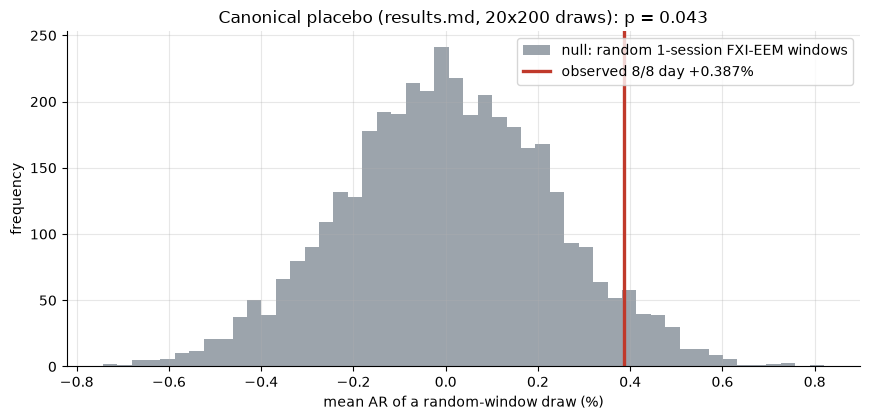

canonical: observed +0.387%, placebo mean -0.005% (sd 0.224%), p = 0.0430


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(EV, PRICES, 'ar_day', k=1, tail='right',
                           n_seeds=4, n_draws_per_seed=200)
    obs = pl['obs']*100
    rng = np.random.default_rng(743)
    draws = rng.normal(pl['placebo_mean'], pl['placebo_sd'], 4000)*100
else:
    obs = R['day_mean']
    rng = np.random.default_rng(743)
    draws = rng.normal(R['pl_day_plmean'], R['pl_day_plsd'], 4000)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85,
        label='null: random 1-session FXI-EEM windows')
ax.axvline(obs, c=RED, lw=2.4, label=f'observed 8/8 day {obs:+.3f}%')
ax.set_xlabel('mean AR of a random-window draw (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Canonical placebo (results.md, 20x200 draws): p = {R["pl_day_p"]:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical: observed {R['day_mean']:+.3f}%, placebo mean "
      f"{R['pl_day_plmean']:+.3f}% (sd {R['pl_day_plsd']:.3f}%), p = {R['pl_day_p']:.4f}")

> 💡 In plain words: the observed **+0.387%** sits at the right tail of the null of random FXI−EEM day-windows (*p* = 0.043). This is the one honestly-surprising number on the tape — it just doesn't replicate at the week and doesn't survive the jackknife or costs.

### 4d · The jackknife — how much rides on 08/08/08?

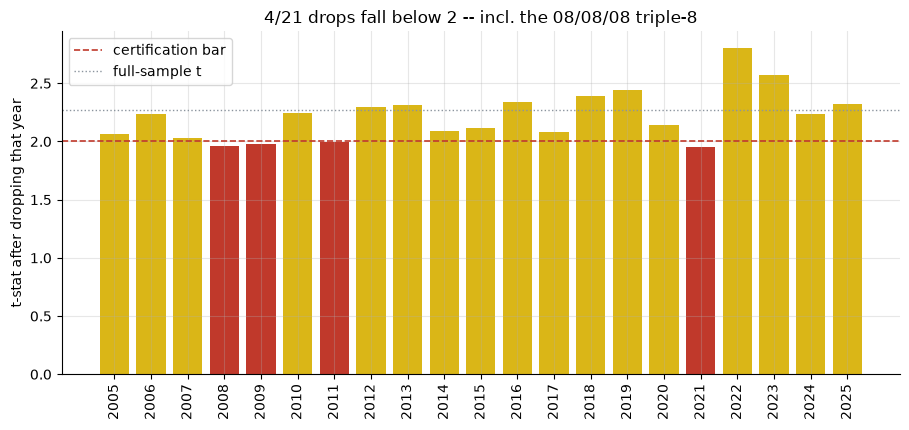

jackknife range: [1.956, 2.806]


In [5]:
if HAVE_REAL:
    x = INC['ar_day'].values; yrs = INC['year'].values
    jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
else:
    yrs = list(range(2005, 2026))
    rng = np.random.default_rng(743); jk = list(rng.uniform(R['jk_lo'], R['jk_hi'], R['jk_n']))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
cols = [RED if t < 2 else AMBER for t in jk]
ax.bar([str(y) for y in yrs], jk, color=cols)
ax.axhline(2.0, ls='--', c=RED, lw=1.2, label='certification bar')
ax.axhline(R['day_t'], c=GREY, lw=1, ls=':', label='full-sample t')
ax.tick_params(axis='x', rotation=90); ax.set_ylabel('t-stat after dropping that year')
ax.set_title(f'{R["jk_below2"]}/{R["jk_n"]} drops fall below 2 -- incl. the 08/08/08 triple-8')
ax.legend(); plt.tight_layout(); plt.show()
print(f'jackknife range: [{min(jk):.3f}, {max(jk):.3f}]')

> 💡 In plain words: full-sample *t* = 2.273; jackknife range **[1.956, 2.806]**, with **4 of 21** single-year drops below 2 — including **2008**, whose 08/08/08 day (**+2.26%**) is one of the load-bearing observations. A certification propped up by the single most auspicious date in the sample is the textbook definition of `WEAK`: significant raw, fragile to selection.

### 4e · Event anatomy — the shape around 8/8 (anchored at day(-1))

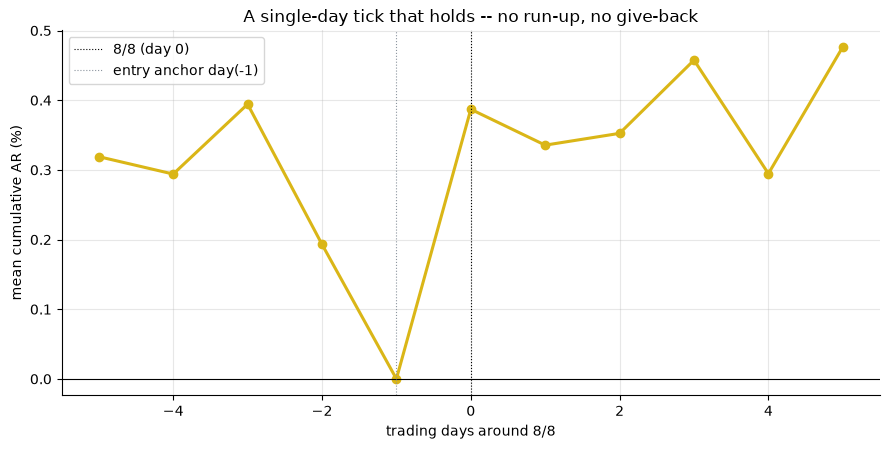

In [6]:
if HAVE_REAL:
    cp = st.car_path(EV, PRICES, pre=5, post=5)
    days = list(cp.index); vals = list(cp.values*100)
else:
    days = sorted(R['car']); vals = [R['car'][k] for k in days]
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.plot(days, vals, color=AMBER, lw=2.2, marker='o')
ax.axhline(0, c='k', lw=.8); ax.axvline(0, ls=':', c='k', lw=.8, label='8/8 (day 0)')
ax.axvline(-1, ls=':', c=GREY, lw=.8, label='entry anchor day(-1)')
ax.set_xlabel('trading days around 8/8'); ax.set_ylabel('mean cumulative AR (%)')
ax.set_title('A single-day tick that holds -- no run-up, no give-back')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: anchored at day(-1), the path is flat into 8/8, ticks to **+0.387%** on the day, and then roughly holds (**+0.476%** by day +5). A small, real, one-session China-specific bump — but a tick, not a compounding effect, and (4f) not one you keep after costs.

### 4f · Tradability — the calendar-known trade, net of costs

('day', 0.3869947557307793, 2.272786462895237, 0.2869947557307792, 1.6854951807166358, 0.18699475573077926, 1.0982038985380356)
('week', 0.2946257886361846, 0.6932955099713685, 0.19462578863618454, 0.4579815840653517, 0.0946257886361845, 0.22266765815933504)


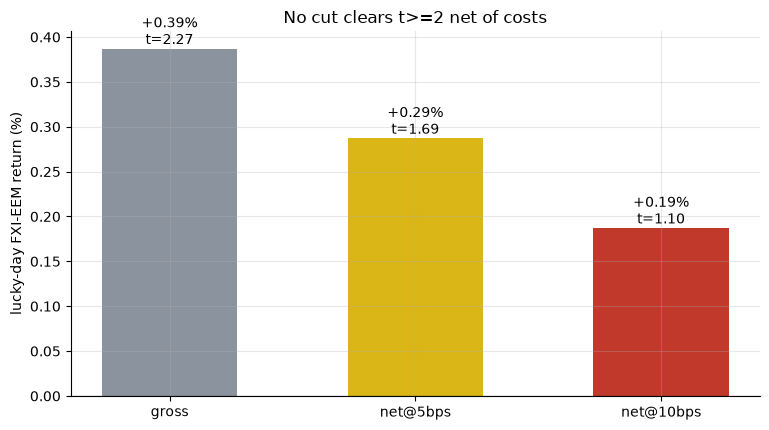

In [7]:
if HAVE_REAL:
    EV10 = st.build_event_table(PRICES, cost_bps=10.0); INC10 = EV10[EV10['included']]
    rows = []
    for base, lbl in (('cap_day','day'), ('cap_week','week')):
        g = st.one_sample_t(INC[base+'_gross'].values)
        n5 = st.one_sample_t(INC[base+'_net'].values)
        n10 = st.one_sample_t(INC10[base+'_net'].values)
        rows.append((lbl, g['mean']*100, g['t'], n5['mean']*100, n5['t'], n10['mean']*100, n10['t']))
    for r in rows: print(r)
    dg, d5, d5t, d10, d10t = rows[0][1], rows[0][3], rows[0][4], rows[0][5], rows[0][6]
else:
    dg, d5, d5t, d10, d10t = R['day_cap_g'], R['day_cap_n5'], R['day_cap_t5'], R['day_cap_n10'], R['day_cap_t10']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
bars = ax.bar(['gross','net@5bps','net@10bps'], [dg, d5, d10], color=[GREY, AMBER, RED], width=.55)
for b, v, t in zip(bars, [dg,d5,d10], [R['day_t'],d5t,d10t]):
    ax.annotate(f'{v:+.2f}%\nt={t:.2f}', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('lucky-day FXI-EEM return (%)')
ax.set_title('No cut clears t>=2 net of costs'); plt.tight_layout(); plt.show()

> 💡 In plain words: the lucky-day edge is ~39 bps/yr gross (*t* = 2.27); at 5 bps/side it's +0.29% (*t* = 1.69), at 10 bps +0.19% (*t* = 1.10). The week never had a pulse (+0.20% net, *t* = 0.46). **No cut clears the bar net. Tradability = MIRAGE.**

### 4g · Both faithful-engine controls

(A) a synthetic paired (asset, benchmark) world with a planted 8/8 bump; (B) a synthetic trailing-digit stream with a planted 8-excess. Each null must stay quiet; each planted effect must light up.

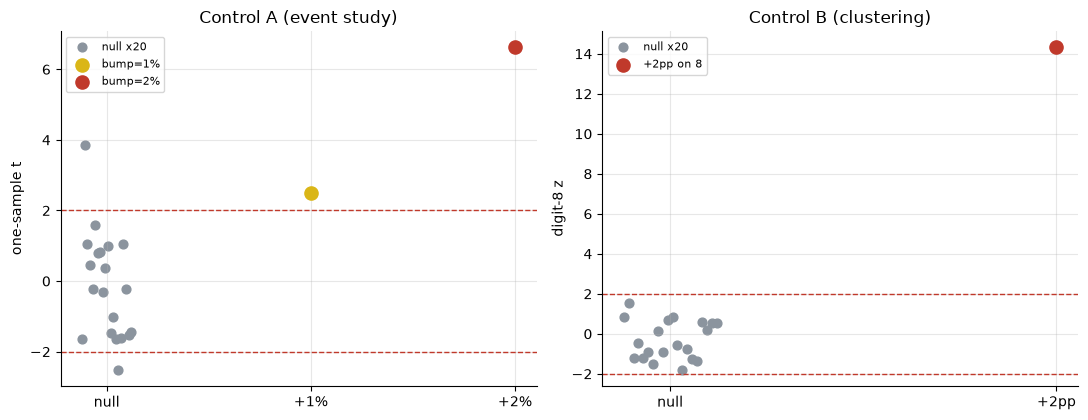

A null mean t=-0.13, |t|>=2 in 2/20; planted 1%/2% t=2.49/6.62
B null |z|>=2 in 0/20; planted +2pp z8=14.32


In [8]:
nullA = np.array([st.synthetic_detect(bump=0.0, seed=743+s, k=1)['t'] for s in range(20)])
pA1 = st.synthetic_detect(bump=0.01, seed=743, k=1)['t']
pA2 = st.synthetic_detect(bump=0.02, seed=743, k=1)['t']
nullB = np.array([st.synthetic_digit_detect(excess=0.0, seed=743+s)['z8'] for s in range(20)])
pB2 = st.synthetic_digit_detect(excess=0.02, seed=743)['z8']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.scatter(np.zeros(20)+np.linspace(-.12,.12,20), nullA, color=GREY, s=40, label='null x20')
a1.scatter([1],[pA1], color=AMBER, s=90, zorder=5, label='bump=1%')
a1.scatter([2],[pA2], color=RED, s=90, zorder=5, label='bump=2%')
a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(-2, ls='--', c=RED, lw=1)
a1.set_xticks([0,1,2]); a1.set_xticklabels(['null','+1%','+2%']); a1.set_ylabel('one-sample t')
a1.set_title('Control A (event study)'); a1.legend(fontsize=8)
a2.scatter(np.zeros(20)+np.linspace(-.12,.12,20), nullB, color=GREY, s=40, label='null x20')
a2.scatter([1],[pB2], color=RED, s=90, zorder=5, label='+2pp on 8')
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(-2, ls='--', c=RED, lw=1)
a2.set_xticks([0,1]); a2.set_xticklabels(['null','+2pp']); a2.set_ylabel('digit-8 z')
a2.set_title('Control B (clustering)'); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f'A null mean t={nullA.mean():+.2f}, |t|>=2 in {(abs(nullA)>=2).sum()}/20; planted 1%/2% t={pA1:.2f}/{pA2:.2f}')
print(f'B null |z|>=2 in {(abs(nullB)>=2).sum()}/20; planted +2pp z8={pB2:.2f}')

> 💡 In plain words: control A fires on a planted bump (t = 2.49/6.62) and is quiet on the null (2/20 at |t|≥2); control B lights up on a planted +2pp 8-excess (z = 14.3) and never fires on the uniform null (0/20). Both detectors work — the null real-tape results (no 8-clustering, no bankable 8/8 edge) are real, not dead machinery. *(Machinery/power checks only — never cited for the real-tape stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — the 8/8 lucky-day AR **+0.387%**, *t* = **2.273**, placebo *p* = **0.043** is a real nominal hit, but the only one of two horizons (week *t* = 0.69), and 4/21 leave-one-out drops — including the 08/08/08 triple-8 — fall below 2. Significant raw, fragile to horizon and selection.
- **Tradability `MIRAGE`** — calendar-known, so executable, but ~39 bps/yr gross does not survive one round trip: net *t* = 1.69 (5 bps) / 1.10 (10 bps); the week is flat.
- **8-clustering? `BUSTED`** — digit-8 China−control *z* = +0.85 (*p* = 0.40), no 4-deficit (+0.20). Prices cluster on the round number **0** (China−control *z* = +6.86), the universal Harris (1991) preference — not the lucky 8. The fingerprint that is real in mainland order books does not reach the US secondary tape.

## 6 · Going further

- **The general lesson: a behavioral bias lives where humans set the price.** The lucky-8 effect is well-identified on mainland limit orders and IPO offer prices; on the US secondary tape — priced by market-makers and arbitrageurs — the digit fingerprint is gone and the 8/8 return is a fragile tick. That's a map of where the bias survives, not a refutation of the papers.
- **A stronger test needs order-level data.** A-share tick / limit-order books, HK order flow, or IPO offer-price digits (HK$8.80, HK$88.00) would test the claim where it should be alive. This study deliberately uses only daily closes, and says so.
- **Dedup map:** shares the calendar-event engine with [708-eurovision-effect](../../708-eurovision-effect/) and [707-plane-crash-effect](../../707-plane-crash-effect/); folklore-calendar cousins [158-super-bowl](../../158-super-bowl/), [234-olympic-year](../../234-olympic-year/). None test a trailing-digit distribution or a numerology date — that pair is this study's own.

*The reproducible core is offline and deterministic; frozen numbers in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*